# Titanic Feature Engineering and Selection

This project analyzes the Titanic dataset to prepare it for machine learning models.

Steps performed:

1. Data Cleaning
2. Feature Engineering
3. Feature Selection

The goal is to identify which passenger characteristics most influence survival.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:

df = pd.read_csv('../data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The data set 13 fields. The Cabin has the most missing values having 687 Null values, followed by Cabin then Embarked with two nulls.

## Data Cleaning
Age:
Missing age values were replaced with the median age because age distribution contains outliers.

Embarked:
Missing values were replaced with the most frequent port.

Cabin:
Cabin contained many missing values. Instead of dropping it completely, the first letter was extracted to represent the deck.

Duplicates:
Duplicate records were removed to maintain dataset consistency.

## Feature Engineering

New features were created to better represent passenger characteristics.

FamilySize:
Calculated as SibSp + Parch + 1. This represents the total family members traveling together.

IsAlone:
Binary feature indicating whether a passenger traveled alone.

Title:
Extracted from passenger names to capture social status.

AgeGroup:
Passengers were categorized into Child, Teen, Adult, and Senior.

FarePerPerson:
Fare divided by FamilySize to approximate ticket cost per individual.

## Feature Selection

Feature selection helps identify which variables contribute most to predicting survival.

Two methods were used:

1. Correlation Analysis
   Used to identify redundant features.

2. Random Forest Feature Importance
   Tree-based models rank features based on their predictive power.

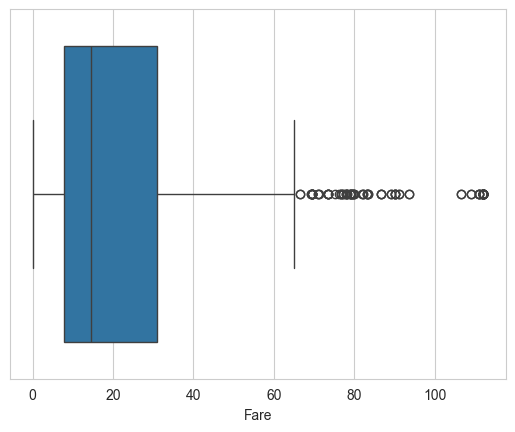

In [14]:
#Visualizing fare and age
sns.boxplot(x=df["Fare"])
plt.show()

In [13]:
#capping extreme values
upper = df["Fare"].quantile(0.95)
df["Fare"] = np.where(df["Fare"] > upper, upper, df["Fare"])

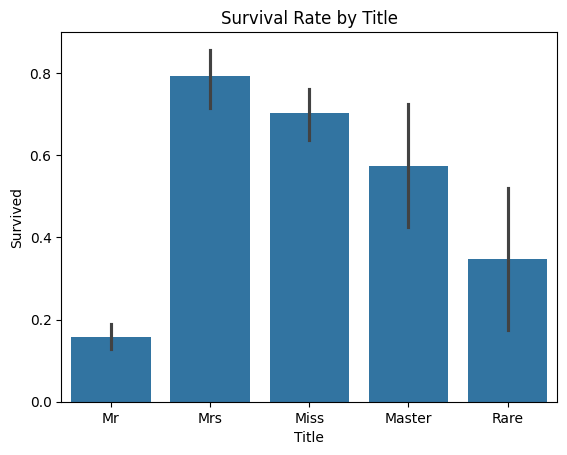

In [ ]:
# 1. Load the data
df = pd.read_csv('../data/train.csv')

# 2. FEATURE ENGINEERING: Extract Title from Name
# This creates the 'Title' column that Seaborn is looking for
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)

# 3. CLEANING: Group rare titles (optional but recommended for a better plot)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 4. NOW run your plot
sns.barplot(x='Title', y='Survived', data=df)
plt.title('Survival Rate by Title')
plt.show()

<Axes: >

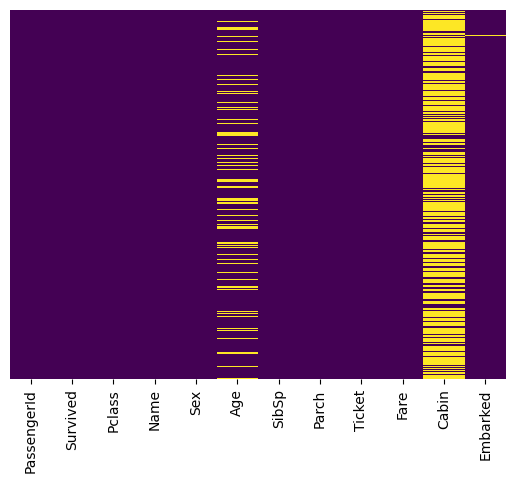

In [5]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

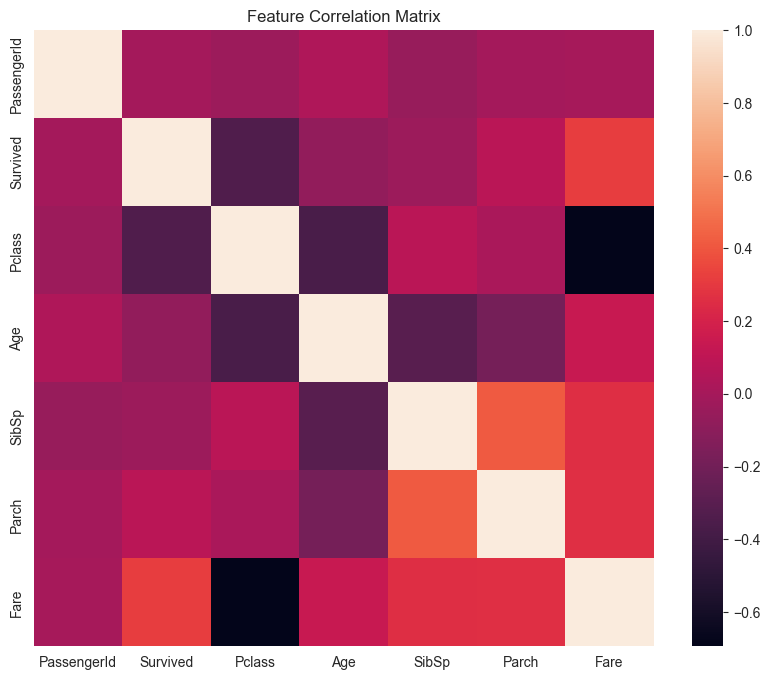

In [16]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

<Axes: xlabel='Survived', ylabel='count'>

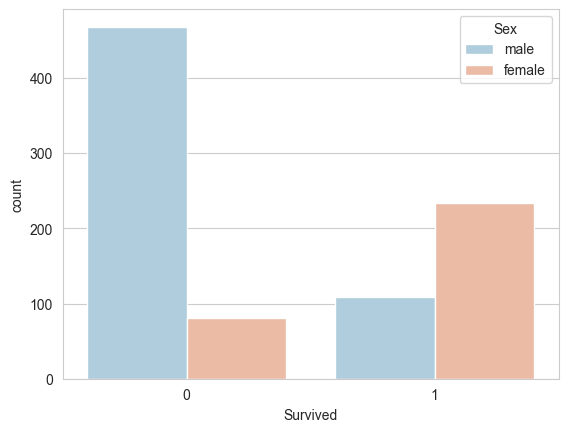

In [7]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=df,palette='RdBu_r')

A Random Forest classifier was used to evaluate feature importance.

The most important predictors of survival were:

• Age – younger passengers had higher survival rates.
• Sex_male – females had significantly higher survival probability.
• Fare_Per_Person – higher ticket cost often corresponded to better survival chances.
• Pclass – passengers in first class had better survival rates.
• Titles (Mr, Miss, Mrs) – extracted from names, capturing gender and social roles.
• Family_Size – passengers traveling with family had slightly different survival outcomes.

These results align with historical accounts of the Titanic disaster where evacuation prioritized women and children.